# **Day 46: K-Means Clustering**
*Module 8 - Unsupervised Learning*

**Unsupervised learning** finds structure in data **without labels**. Clustering groups similar samples: customer segments, gene expression patterns, unsupervised land-cover classes (the classic ISODATA / K-Means classification of satellite images), and colour quantisation.

> K-means groups unlabelled data into k clusters by placing k centres and assigning each point to the nearest one, repeating until stable. It is fast and simple but assumes round, similar-sized clusters.
>
> *Example:* Unsupervised classification of an image into 6 spectral clusters, which an analyst then names (water, forest, and so on), is K-means.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler
rng = np.random.default_rng(46)

## **1. The Objective and Lloyd's Algorithm**
K-Means finds $K$ centroids $\boldsymbol\mu_k$ minimising the **within-cluster sum of squares (inertia)**:
$$J = \sum_{i=1}^n \min_k \lVert\mathbf x_i - \boldsymbol\mu_k\rVert^2$$
Lloyd's algorithm alternates two steps until nothing changes:
1. **Assign** each point to its nearest centroid.
2. **Update** each centroid to the mean of its points.
Each step can only lower $J$, so it converges, but only to a **local** minimum.

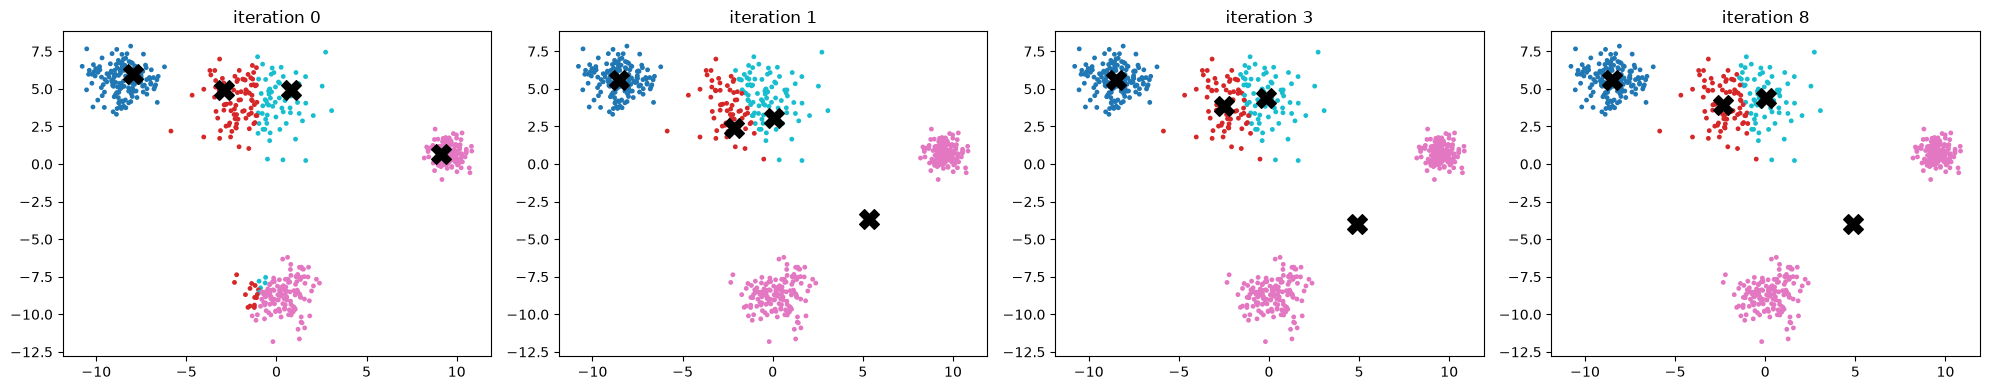

scratch, ONE random start: inertia 14281.2 | sklearn (k-means++ init, 10 restarts): 1324.9
If the scratch value is much larger, this random start got stuck in a poor local minimum (two centroids in one blob): see Section 2.


In [2]:
def kmeans_scratch(X, k, n_iter=100, seed=0, init=None):
    r = np.random.default_rng(seed)
    C = X[r.choice(len(X), k, replace=False)] if init is None else init.copy()
    history = [C.copy()]
    for _ in range(n_iter):
        labels = np.argmin(((X[:, None, :] - C[None]) ** 2).sum(-1), axis=1)       # assignment step
        C_new = np.array([X[labels == j].mean(0) if np.any(labels == j) else C[j] for j in range(k)])   # update step
        history.append(C_new.copy())
        if np.allclose(C_new, C):
            break
        C = C_new
    inertia = ((X - C[labels]) ** 2).sum()
    return labels, C, inertia, history

X, y_true = make_blobs(600, centers=4, cluster_std=[1.0, 1.5, 0.6, 1.0], random_state=7)
labels, C, inertia, hist = kmeans_scratch(X, 4, seed=3)
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, it in zip(axes, [0, 1, 3, len(hist) - 1]):
    lab = np.argmin(((X[:, None] - hist[it][None]) ** 2).sum(-1), 1)
    ax.scatter(*X.T, c=lab, s=6, cmap="tab10"); ax.scatter(*hist[it].T, c="k", marker="X", s=200)
    ax.set_title(f"iteration {it}")
plt.tight_layout(); plt.show()
print(f"scratch, ONE random start: inertia {inertia:.1f} | sklearn (k-means++ init, 10 restarts): {KMeans(4, n_init=10, random_state=0).fit(X).inertia_:.1f}")
print("If the scratch value is much larger, this random start got stuck in a poor local minimum (two centroids in one blob): see Section 2.")

## **2. Initialisation Matters: K-Means++ and Restarts**
Random initial centroids can converge to poor local minima. **K-Means++** (Arthur & Vassilvitskii, 2007) picks each new initial centroid with probability proportional to its squared distance from the existing ones: spread-out starts. scikit-learn also runs `n_init` restarts and keeps the best.

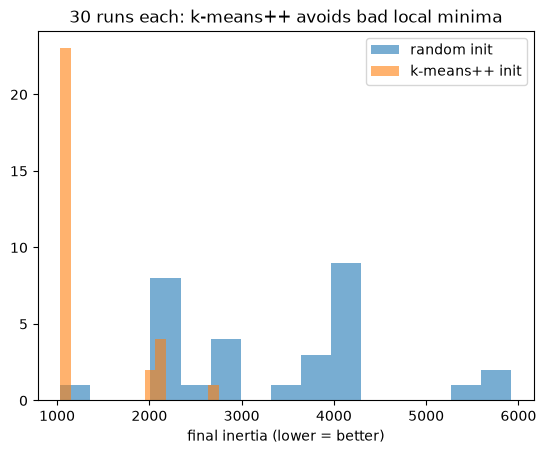

In [3]:
def kmeanspp_init(X, k, seed=0):
    r = np.random.default_rng(seed); C = [X[r.integers(len(X))]]
    for _ in range(k - 1):
        d2 = np.min(((X[:, None] - np.array(C)[None]) ** 2).sum(-1), axis=1)
        C.append(X[r.choice(len(X), p=d2 / d2.sum())])
    return np.array(C)

Xh, _ = make_blobs(1500, centers=10, cluster_std=0.6, random_state=11)
rand_inertia = [kmeans_scratch(Xh, 10, seed=s)[2] for s in range(30)]
pp_inertia = [kmeans_scratch(Xh, 10, init=kmeanspp_init(Xh, 10, seed=s))[2] for s in range(30)]
plt.hist(rand_inertia, bins=15, alpha=0.6, label="random init"); plt.hist(pp_inertia, bins=15, alpha=0.6, label="k-means++ init")
plt.xlabel("final inertia (lower = better)"); plt.legend(); plt.title("30 runs each: k-means++ avoids bad local minima"); plt.show()

## **3. Choosing K**
- **Elbow**: inertia always decreases with K; look for the bend.
- **Silhouette**: for each sample $s = \frac{b-a}{\max(a,b)}$, $a$ = mean distance to own cluster, $b$ = to nearest other cluster. Range -1..1; higher is better.
- **Gap statistic** (Tibshirani et al., 2001): compare $\log J_K$ with that of uniform reference data.

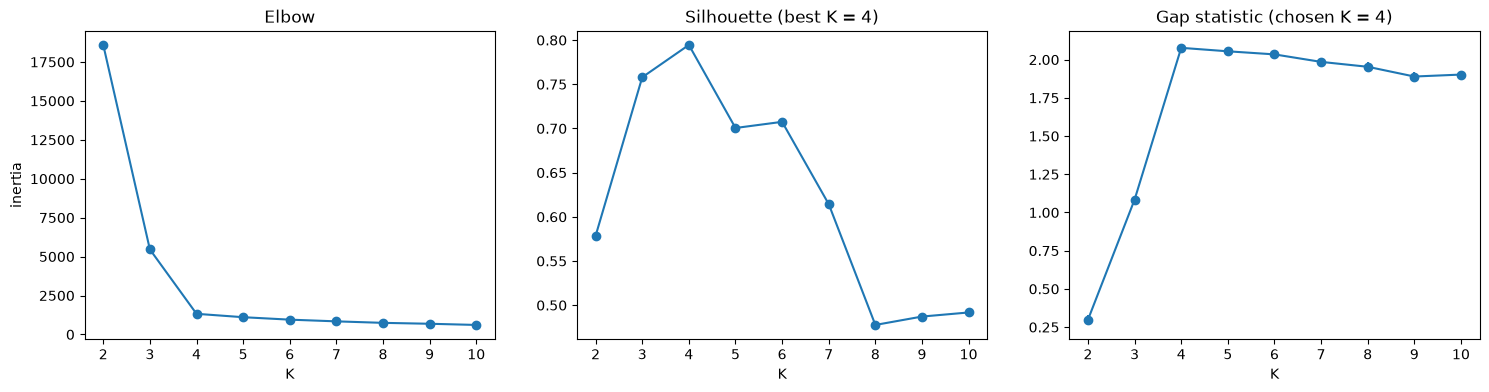

In [4]:
Ks = range(2, 11)
inertias, sils = [], []
for k in Ks:
    km = KMeans(k, n_init=10, random_state=0).fit(X)
    inertias.append(km.inertia_); sils.append(silhouette_score(X, km.labels_))

def gap_statistic(X, Ks, B=10, seed=0):
    r = np.random.default_rng(seed); lo, hi = X.min(0), X.max(0); gaps, sks = [], []
    for k in Ks:
        Wk = np.log(KMeans(k, n_init=5, random_state=0).fit(X).inertia_)
        Wb = np.array([np.log(KMeans(k, n_init=3, random_state=b).fit(r.uniform(lo, hi, X.shape)).inertia_) for b in range(B)])
        gaps.append(Wb.mean() - Wk); sks.append(Wb.std() * np.sqrt(1 + 1 / B))
    return np.array(gaps), np.array(sks)
gaps, sks = gap_statistic(X, Ks)
best_gap_k = [k for i, k in enumerate(list(Ks)[:-1]) if gaps[i] >= gaps[i + 1] - sks[i + 1]][0]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(Ks, inertias, "o-"); axes[0].set(title="Elbow", xlabel="K", ylabel="inertia")
axes[1].plot(Ks, sils, "o-"); axes[1].set(title=f"Silhouette (best K = {list(Ks)[int(np.argmax(sils))]})", xlabel="K")
axes[2].errorbar(Ks, gaps, yerr=sks, fmt="o-"); axes[2].set(title=f"Gap statistic (chosen K = {best_gap_k})", xlabel="K")
plt.show()

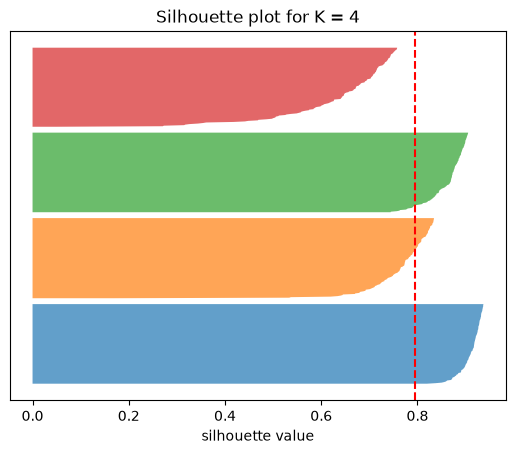

In [5]:
km4 = KMeans(4, n_init=10, random_state=0).fit(X); s_vals = silhouette_samples(X, km4.labels_)
y_low = 10
for c in range(4):
    v = np.sort(s_vals[km4.labels_ == c]); plt.fill_betweenx(np.arange(y_low, y_low + len(v)), 0, v, alpha=0.7); y_low += len(v) + 10
plt.axvline(s_vals.mean(), c="r", ls="--"); plt.xlabel("silhouette value"); plt.yticks([]); plt.title("Silhouette plot for K = 4"); plt.show()

## **4. Assumptions and Failure Modes**
K-Means assumes clusters are **convex, roughly spherical, similar in size and spread**, and that Euclidean distance is meaningful (scale our features!).

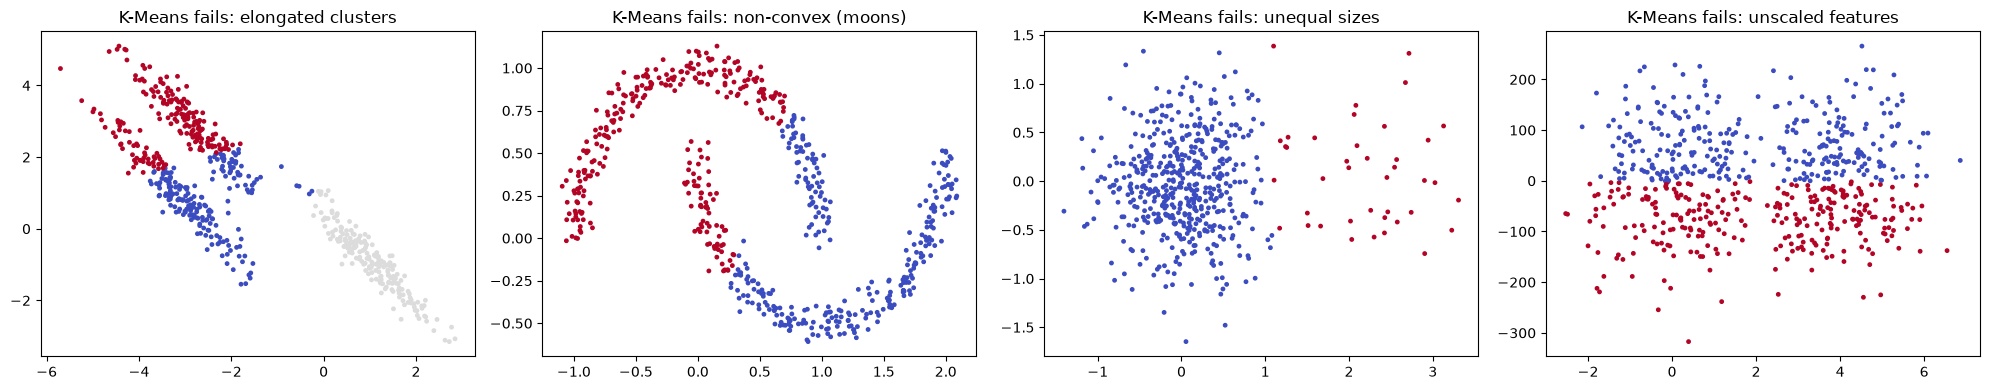

In [6]:
from sklearn.datasets import make_moons
X_aniso = make_blobs(600, centers=3, random_state=170)[0] @ np.array([[0.6, -0.6], [-0.4, 0.8]])
X_moons = make_moons(600, noise=0.06, random_state=0)[0]
X_unequal = np.vstack([rng.normal([0, 0], 0.5, (500, 2)), rng.normal([2.5, 0], 0.5, (30, 2))])
X_scale = np.c_[rng.normal(0, 1, 600), rng.normal(0, 100, 600)]; X_scale[:300, 0] += 4
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, D, k) in zip(axes, [("elongated clusters", X_aniso, 3), ("non-convex (moons)", X_moons, 2),
                                    ("unequal sizes", X_unequal, 2), ("unscaled features", X_scale, 2)]):
    ax.scatter(*D.T, c=KMeans(k, n_init=10, random_state=0).fit_predict(D), s=6, cmap="coolwarm"); ax.set_title(f"K-Means fails: {name}")
plt.tight_layout(); plt.show()

Remedies: scale features; use Gaussian mixtures for elliptical clusters (Day 48); DBSCAN / spectral clustering for non-convex shapes (Day 47).

## **5. Unsupervised Image Classification by Colour/Spectral Clustering**
The classic unsupervised land-cover workflow: reshape the image to a pixel table (Day 3), cluster pixels, reshape back, then **label the clusters** by inspection. MiniBatch K-Means scales to millions of pixels.

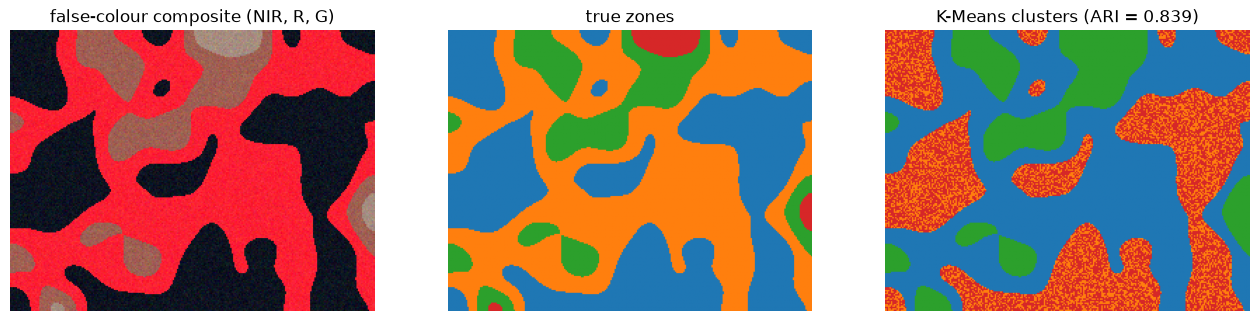

Cluster centroids (mean spectra) -> use them to name the clusters:
        B      G      R    NIR
0  0.050  0.080  0.050  0.400
1  0.060  0.063  0.026  0.028
2  0.109  0.138  0.158  0.251
3  0.060  0.043  0.032  0.016


In [7]:
from scipy.ndimage import gaussian_filter
H, W = 200, 260
field = gaussian_filter(rng.normal(size=(H, W)), 12); field = (field - field.min()) / np.ptp(field)
classes = np.digitize(field, [0.35, 0.55, 0.75])                                   # 4 "true" land-cover zones
spectra = np.array([[0.06, 0.05, 0.03, 0.02], [0.05, 0.08, 0.05, 0.40], [0.10, 0.13, 0.15, 0.25], [0.18, 0.20, 0.22, 0.26]])
img = spectra[classes] + rng.normal(0, 0.015, (H, W, 4))                           # water, vegetation, crop/soil, urban
pixels = img.reshape(-1, 4)
mbk = MiniBatchKMeans(4, batch_size=4096, n_init=5, random_state=0).fit(pixels)
cluster_map = mbk.labels_.reshape(H, W)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].imshow(np.clip(img[..., [3, 2, 1]] * 2.5, 0, 1)); axes[0].set_title("false-colour composite (NIR, R, G)")
axes[1].imshow(classes, cmap="tab10", vmax=9); axes[1].set_title("true zones")
axes[2].imshow(cluster_map, cmap="tab10", vmax=9); axes[2].set_title(f"K-Means clusters (ARI = {adjusted_rand_score(classes.ravel(), mbk.labels_):.3f})")
for ax in axes: ax.axis("off")
plt.show()
print("Cluster centroids (mean spectra) -> use them to name the clusters:\n", pd.DataFrame(mbk.cluster_centers_, columns=["B", "G", "R", "NIR"]).round(3))

# **Part 2: Going Deeper**

### External validation: ARI and NMI
When true labels exist (for evaluation only), compare partitions with label-permutation-invariant scores:
- **Adjusted Rand Index (ARI)**: pair-counting agreement corrected for chance (0 = random, 1 = identical).
- **Normalised Mutual Information (NMI)**: shared information between partitions (Day 12).

In [8]:
for k in [2, 3, 4, 5, 8]:
    lab = KMeans(k, n_init=10, random_state=0).fit_predict(X)
    print(f"K = {k}: ARI {adjusted_rand_score(y_true, lab):.3f} | NMI {normalized_mutual_info_score(y_true, lab):.3f} | silhouette {silhouette_score(X, lab):.3f}")

K = 2: ARI 0.486 | NMI 0.637 | silhouette 0.579
K = 3: ARI 0.709 | NMI 0.844 | silhouette 0.758
K = 4: ARI 0.996 | NMI 0.993 | silhouette 0.795
K = 5: ARI 0.914 | NMI 0.942 | silhouette 0.701


K = 8: ARI 0.675 | NMI 0.812 | silhouette 0.478

### K-Means as vector quantisation (compression)
Replace each pixel by its centroid: an image with millions of colours is stored with K colours + an index map.

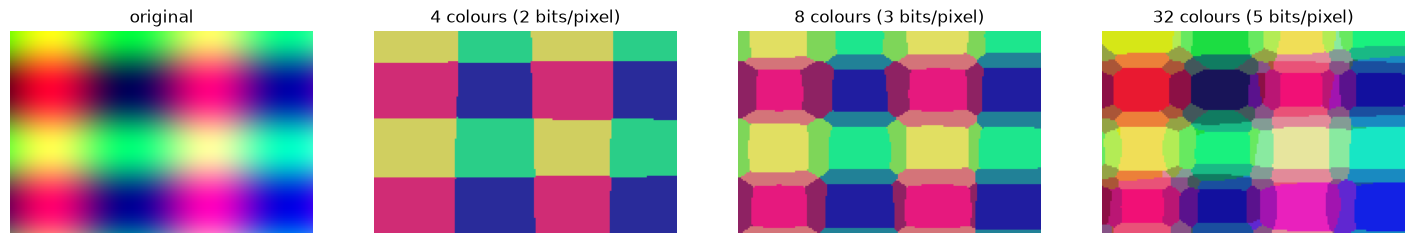

In [9]:
yy, xx = np.mgrid[0:120, 0:180]
photo = np.stack([0.5 + 0.5 * np.sin(xx / 15), 0.5 + 0.5 * np.cos(yy / 11), (xx + yy) / 300], -1).clip(0, 1)
fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
axes[0].imshow(photo); axes[0].set_title("original"); axes[0].axis("off")
for ax, k in zip(axes[1:], [4, 8, 32]):
    q = MiniBatchKMeans(k, n_init=3, random_state=0).fit(photo.reshape(-1, 3))
    ax.imshow(q.cluster_centers_[q.labels_].reshape(photo.shape)); ax.set_title(f"{k} colours ({np.log2(k):.0f} bits/pixel)"); ax.axis("off")
plt.show()

## **Practice Problems**
1. Run `kmeans_scratch` with 20 random seeds on `Xh` and plot the distribution of final inertia. How often is the best solution found?
2. On the wine dataset (`load_wine`), compare K-Means ARI with and without standardisation.
3. Cluster the synthetic image with K = 6. What happens to the zones (over-segmentation)?
4. *(Advanced)* Implement **K-Medoids** (PAM-style: medoids must be data points, use L1 distance) for a small dataset and compare robustness to outliers with K-Means.

In [10]:
# Solution 1
inert = np.array([kmeans_scratch(Xh, 10, seed=s)[2] for s in range(20)])
print(f"best inertia reached in {np.mean(np.isclose(inert, inert.min(), rtol=1e-3)):.0%} of random-init runs")
# Solution 2
from sklearn.datasets import load_wine
Xw, yw = load_wine(return_X_y=True)
print("ARI raw:", round(adjusted_rand_score(yw, KMeans(3, n_init=10, random_state=0).fit_predict(Xw)), 3),
      "| scaled:", round(adjusted_rand_score(yw, KMeans(3, n_init=10, random_state=0).fit_predict(StandardScaler().fit_transform(Xw))), 3))
# Solution 3
lab6 = MiniBatchKMeans(6, n_init=5, random_state=0).fit_predict(pixels)
print("K = 6 contingency (rows = true zones, cols = clusters):\n", pd.crosstab(classes.ravel(), lab6))
# Solution 4
def kmedoids(X, k, n_iter=50, seed=0):
    r = np.random.default_rng(seed); D = np.abs(X[:, None] - X[None]).sum(-1); med = r.choice(len(X), k, replace=False)
    for _ in range(n_iter):
        lab = D[:, med].argmin(1)
        new = np.array([np.flatnonzero(lab == j)[D[np.ix_(lab == j, lab == j)].sum(1).argmin()] for j in range(k)])
        if set(new) == set(med): break
        med = new
    return lab, X[med]
Xo = np.vstack([rng.normal([0, 0], 0.5, (100, 2)), rng.normal([4, 0], 0.5, (100, 2)), [[40, 40], [42, 38]]])
print("K-Means centres:\n", KMeans(2, n_init=10, random_state=0).fit(Xo).cluster_centers_.round(2))
print("K-Medoids centres:\n", kmedoids(Xo, 2)[1].round(2))

best inertia reached in 5% of random-init runs
ARI raw: 0.371 | scaled: 0.897
K = 6 contingency (rows = true zones, cols = clusters):
 col_0      0     1     2      3      4    5
row_0                                      
0          0  9504     0      0  10053    0
1      11632     0     0  12635      0    0
2          0     0  7183      0      0    0
3          0     0     0      0      0  993
K-Means centres:
 [[2.03e+00 4.00e-02]
 [4.10e+01 3.90e+01]]
K-Medoids centres:
 [[4.08 0.16]
 [0.04 0.01]]


## **Key References**
- Lloyd, S. (1982). Least squares quantization in PCM. *IEEE Transactions on Information Theory*, 28(2), 129-137.
- MacQueen, J. (1967). Some methods for classification and analysis of multivariate observations. *Proceedings of the 5th Berkeley Symposium*, 1, 281-297.
- Arthur, D., & Vassilvitskii, S. (2007). k-means++: The advantages of careful seeding. *SODA 2007*, 1027-1035.
- Tibshirani, R., Walther, G., & Hastie, T. (2001). Estimating the number of clusters in a data set via the gap statistic. *Journal of the Royal Statistical Society B*, 63(2), 411-423.
- Rousseeuw, P. J. (1987). Silhouettes: a graphical aid to the interpretation and validation of cluster analysis. *Journal of Computational and Applied Mathematics*, 20, 53-65.
- Hubert, L., & Arabie, P. (1985). Comparing partitions. *Journal of Classification*, 2(1), 193-218.